<a href="https://colab.research.google.com/github/useroo5/MachineLearning/blob/main/intro_to_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



Установка модуля для обработки естественного языка.





In [1]:
!pip install nltk

Импорт вспомогательных библиотек для работы с разпознаванием речи, а также скачивание отзывов о фильмах, на которых училась модель.


In [2]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('movie_reviews')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


True

Импорт отзывов с библитотеки, и сортировка отзывов по их категории и айди файла.

In [3]:
from nltk.corpus import movie_reviews
import random

documents = [(list(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]
random.shuffle(documents)

print(documents[10])

(['i', "'", 'm', 'not', 'sure', 'if', 'silvio', 'horta', 'wrote', 'urban', 'legend', 'before', 'or', 'after', 'the', 'success', 'of', 'scream', ',', 'but', 'i', "'", 'm', 'guessing', 'after', 'just', 'because', 'it', 'seems', 'he', 'may', 'not', 'have', 'had', 'time', 'to', 'write', 'a', 'second', 'draft', '.', 'seriously', ',', 'this', 'idea', '--', 'a', 'psycho', 'bumping', 'off', 'people', 'in', 'the', 'style', 'of', 'urban', 'legends', '--', 'is', 'a', 'great', 'one', 'and', 'i', 'wish', 'it', 'could', 'have', 'been', 'pulled', 'off', '.', 'the', 'first', 'sign', 'of', 'trouble', 'comes', 'with', 'the', 'painfully', 'insipid', 'dialogue', '.', 'an', 'example', ':', '"', 'that', '[', 'car', 'crash', ']', 'must', "'", 've', 'been', 'awful', '.', '.', '.', 'for', 'everyone', 'involved', '.', '"', 'you', 'can', 'tell', 'that', 'the', 'writer', 'intended', 'that', 'something', 'a', 'little', 'more', 'airy', 'was', 'supposed', 'to', 'have', 'been', 'said', ',', 'just', 'no', 'one', 'figu

# Оброботка текста

In [8]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# d = {} -> dict() -> {'key': 'value', 'key2': 'value2'}
# set = set() -> {'apple', 'pum', 'lemon'}
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

def clear_words(words: list) -> list:
  return [ps.stem(w.lower()) for w in words if w.isalpha() and w.lower() not in stop_words]

In [9]:
print(stop_words)

{'itself', 'hers', 'weren', 't', "should've", 'hasn', 'an', 'own', 're', 'themselves', 'than', 'd', 'under', 'there', "we're", 'so', 'most', 'these', 'above', "he'd", "hasn't", 'all', "isn't", 'll', "she'll", 'before', 'those', "weren't", 'again', 'ours', 'i', 'yourselves', "mightn't", "it'll", 'after', "i've", 'have', 'theirs', 'more', 'by', 'what', 'won', "hadn't", 'other', 'her', 'not', 'shan', 'do', 'was', 'out', 'with', 'you', "doesn't", 'only', "you've", 'ain', 'being', 'has', 'once', 'don', 'me', 'been', 'both', "haven't", 'in', "couldn't", "she'd", 'their', 'its', 'some', "they'd", 'be', 'but', "wouldn't", "you're", 'until', 'off', 'from', 'very', 'yours', 'yourself', 'is', "she's", "he's", "shan't", 'further', 'any', 'and', 'our', 'am', "i'll", 'into', 'on', "it's", 'o', 'we', 'isn', 'or', 'herself', 'against', 'can', 'does', 'having', 'wasn', 'now', 'of', 've', "they'll", 'few', "aren't", "they've", 'too', 'each', 'mightn', 'through', 'then', 'below', 'himself', 'didn', 'no',

In [10]:
cleaned_documents = [(" ".join(clear_words(doc)), label) for doc, label in documents]

In [13]:
print(cleaned_documents[10])

('sure silvio horta wrote urban legend success scream guess seem may time write second draft serious idea psycho bump peopl style urban legend great one wish could pull first sign troubl come pain insipid dialogu exampl car crash must aw everyon involv tell writer intend someth littl airi suppos said one figur know slasher movi suppos lot great character mind cardboard cutout pleas let cutout damn bland one reason movi like scream star war diva becom treasur featur charismat actor play interest charact asid jare leto joshua jackson screen long enough one urban legend make grade alicia witt show none acerb wit display cybil rebecca gayheart actual look unattract mention dumb post film robert englund cruis auto pilot good thing brad dourif wait movi five minut redo good natur stutter charact one flew cuckoo nest bring anoth aspect urban legend unorigin film blatantli rip scream anoth reason make think silvio horta wrote craven williamson great success urban legend tri deconstruct modern 

In [16]:
df = pd.DataFrame(cleaned_documents, columns=['review', 'label'])
df.head(11)

,review,label
0,susan granger review closet miramax film hilar...,pos
1,homicid bad b movi prophet question ask one le...,neg
2,seri erot thriller flood videoshelv earli came...,neg
3,law crowd pleas romant movi state two lead mus...,neg
4,major spoiler film forwarn appear till later a...,pos
5,got love disney matter serv guarante success l...,pos
6,burnt money perfect festiv film show twice one...,neg
7,synopsi al simmon top notch assasin guilti con...,neg
8,folk disney common decenc resurrect yet anoth ...,neg
9,concept seem patent hopeless begin live action...,neg


<Axes: title={'center': 'Кол-во отзывов'}, xlabel='label'>

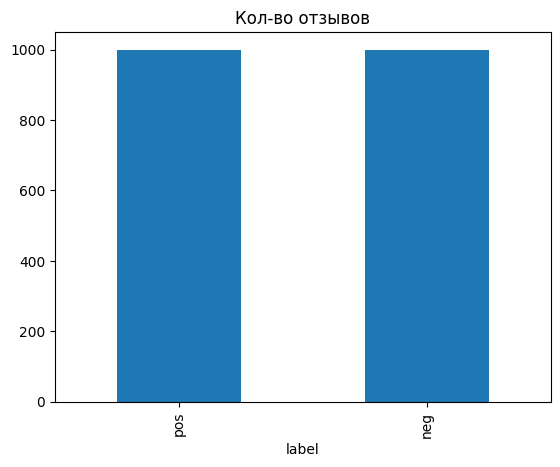

In [19]:
df['label'].value_counts().plot(kind = "bar", title = 'Кол-во отзывов')

In [20]:
from numpy import vectorize
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['review'])
y = df['label']

In [22]:
print(X)
print(y)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 501022 stored elements and shape (2000, 25258)>
  Coords	Values
  (0, 21682)	1
  (0, 9118)	2
  (0, 18412)	1
  (0, 3971)	2
  (0, 14191)	1
  (0, 7714)	1
  (0, 10034)	1
  (0, 8234)	1
  (0, 7453)	1
  (0, 19858)	1
  (0, 2389)	1
  (0, 121)	1
  (0, 5105)	2
  (0, 1231)	1
  (0, 14793)	1
  (0, 8176)	1
  (0, 16622)	5
  (0, 5807)	1
  (0, 8901)	1
  (0, 7770)	1
  (0, 11536)	3
  (0, 4291)	2
  (0, 7371)	2
  (0, 12922)	1
  (0, 5935)	1
  :	:
  (1999, 5241)	1
  (1999, 23565)	1
  (1999, 21453)	1
  (1999, 9168)	1
  (1999, 24176)	1
  (1999, 22908)	2
  (1999, 14459)	1
  (1999, 18188)	1
  (1999, 9554)	1
  (1999, 17979)	1
  (1999, 13134)	1
  (1999, 4195)	1
  (1999, 636)	1
  (1999, 24976)	1
  (1999, 16431)	2
  (1999, 4303)	2
  (1999, 3922)	2
  (1999, 6117)	1
  (1999, 9097)	1
  (1999, 5028)	2
  (1999, 21724)	2
  (1999, 23706)	1
  (1999, 23827)	1
  (1999, 24220)	1
  (1999, 21072)	1
0       pos
1       neg
2       neg
3       neg
4       pos
       ... 
1

In [24]:
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
model = MultinomialNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.785


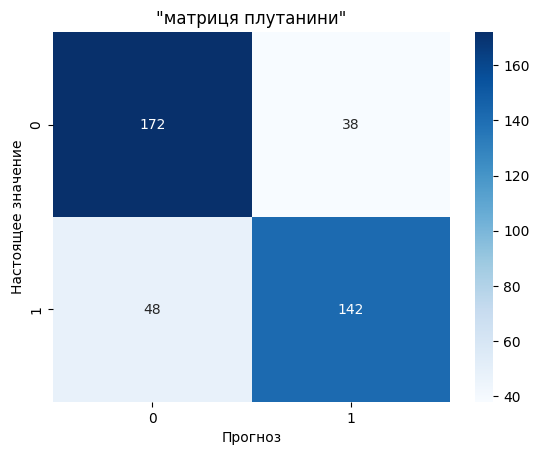

In [30]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = 'd', cmap ='Blues')
plt.xlabel('Прогноз')
plt.ylabel('Настоящее значение')
plt.title('"матриця плутанини"')
plt.show()